# Elevation Analysis Pipeline - Testing Notebook
Complete end-to-end test with parametrized code

**Goal**: Replicate original Oct 23 pipeline logic with new fully-parametrized codebase

## Cell 1: Setup Path & Imports

In [1]:
import os, sys, json, math, inspect
import numpy as np
import pandas as pd
import importlib
import pathlib


# ===== PATH SETUP =====
# Notebook is in: <repo>/uchicago-elevation/scripts/
# Project root is: <repo>/uchicago-elevation/
# Source code is: <repo>/uchicago-elevation/src/

NB_DIR = os.getcwd()
PROJ_ROOT = os.path.dirname(NB_DIR)  # Go up one level to uchicago-elevation/
SRC = os.path.join(PROJ_ROOT, "src")

# Ensure src is at front of sys.path
if SRC not in sys.path:
    sys.path.insert(0, SRC)
importlib.invalidate_caches()

# ===== DIAGNOSTIC OUTPUT =====
print("="*80)
print("PATH DIAGNOSTICS")
print("="*80)
print(f"Notebook dir:     {NB_DIR}")
print(f"Project root:     {PROJ_ROOT}")
print(f"SRC dir:          {SRC}")
print(f"SRC exists?       {os.path.exists(SRC)}")
print(f"\nKey files:")
print(f"  dem.py:         {os.path.exists(os.path.join(SRC, 'elevation', 'dem.py'))}")
print(f"  osm.py:         {os.path.exists(os.path.join(SRC, 'elevation', 'osm.py'))}")
print(f"  terrain.py:     {os.path.exists(os.path.join(SRC, 'elevation', 'terrain.py'))}")
print(f"  viz.py:         {os.path.exists(os.path.join(SRC, 'elevation', 'viz.py'))}")
print(f"  pipeline.py:    {os.path.exists(os.path.join(SRC, 'elevation', 'pipeline.py'))}")
print(f"  __init__.py:    {os.path.exists(os.path.join(SRC, 'elevation', '__init__.py'))}")

# Set outputs directory
outputs_dir = os.path.join(PROJ_ROOT, "outputs")
os.makedirs(outputs_dir, exist_ok=True)
print(f"\nOutputs dir:      {outputs_dir}")
print("="*80)

PATH DIAGNOSTICS
Notebook dir:     /Users/yaoyiyang/Desktop/Uchicago-elevation/scripts
Project root:     /Users/yaoyiyang/Desktop/Uchicago-elevation
SRC dir:          /Users/yaoyiyang/Desktop/Uchicago-elevation/src
SRC exists?       True

Key files:
  dem.py:         True
  osm.py:         True
  terrain.py:     True
  viz.py:         True
  pipeline.py:    True
  __init__.py:    True

Outputs dir:      /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs


## Cell 2: Import All Modules

In [2]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

from elevation.run_final_pipeline import PipelineConfig, run_pipeline


In [ ]:
import os, sys
# 让 Python 能找到 src/
sys.path.insert(0, os.path.join(os.getcwd(), "src"))

print("\n" + "="*80)
print("IMPORTING MODULES (FINAL)")
print("="*80)

# —— 都用包名导入；不要任何 try/except 兜底 ——
from elevation.osm import fetch_building_osm
print("✓ elevation.osm")

from elevation.dem import (
    discover_usgs_lidar_dataset, build_multiple_dems, load_dem, build_all_circle_masks
)
print("✓ elevation.dem")

from elevation.terrain import (
    estimate_house_ground_adaptive, derive_slope_aspect_curvature, classify_terrain_adaptive
)
print("✓ elevation.terrain")

from elevation.analytics import (
    ring_metrics_for_radii, build_multiscale_summary_df, area_level_summary
)
print("✓ elevation.analytics")

from elevation.viz import (
    figure1_elevation, figure2_slope, figure3_aspect, figure4_terrain_and_hist,
    add_3d_figures_to_pipeline, DEFAULT_CONFIG
)
print("✓ elevation.viz")

from elevation.run_final_pipeline import PipelineConfig, run_pipeline
print("✓ elevation.run_final_pipeline")

print("\n✅ ALL IMPORTS SUCCESSFUL")
print("="*80)



IMPORTING MODULES (FINAL)
✓ elevation.osm
✓ elevation.dem
✓ elevation.terrain
✓ elevation.analytics
✓ elevation.viz
✓ elevation.run_final_pipeline

✅ ALL IMPORTS SUCCESSFUL


## Cell 3: Test Location Input (Example 1: Naples, FL)

In [4]:
print("\n" + "="*80)
print("TEST 1")
print("="*80)

# ===== USER INPUT =====
test_lat = 29.0546188
test_lon = -81.3271432

# ===== CREATE CONFIG =====
config = PipelineConfig()

# Set location
config.lat = test_lat
config.lon = test_lon

# ===== CUSTOMIZE PARAMETERS (ALL PARAMETRIZED!) =====
config.aoi_radius_m = 100.0               # User-selectable AOI
config.osm_buffer_m = 120.0               # OSM search radius
config.dem_resolution_m = 1.0
config.dem_for_user_aoi = True
config.reference_radius_m = 500.0

# Ring metrics radii (parametrized!)
config.ring_metrics_radii = [50.0, 200.0, 500.0]

# Terrain thresholds (parametrized!)
config.slope_low_threshold = 2.0
config.slope_mod_threshold = 5.0

# House estimation (all parametrized!)
config.min_size_edge = 10
config.min_size_ring_3_8 = 20
config.min_size_ring_8_15 = 30
config.min_size_ring_15_30 = 50
config.q_high_tail_threshold = 98.0
config.hard_q_high_tail = 99.5

# Output settings
config.output_dir = outputs_dir
config.output_format = "csv"             # parquet + csv
config.generate_narrative = True
config.save_3d = True
config.verbose = True

print(f"\nConfig Summary:")
print(f"  Location:              {config.lat}, {config.lon}")
print(f"  AOI radius:            {config.aoi_radius_m}m (user-selectable!)")
print(f"  OSM buffer:            {config.osm_buffer_m}m")
print(f"  Ring metrics radii:    {config.ring_metrics_radii}")
print(f"  Slope thresholds:      {config.slope_low_threshold}°, {config.slope_mod_threshold}°")
print(f"  Output dir:            {config.output_dir}")
print("="*80)


TEST 1

Config Summary:
  Location:              29.0546188, -81.3271432
  AOI radius:            100.0m (user-selectable!)
  OSM buffer:            120.0m
  Ring metrics radii:    [50.0, 200.0, 500.0]
  Slope thresholds:      2.0°, 5.0°
  Output dir:            /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs


## Cell 4: Run Pipeline (Main Execution)

In [6]:
print("\n" + "="*80)
print("EXECUTING PIPELINE")
print("="*80)

try:
    results = run_pipeline(config)
    print("\n✅ PIPELINE EXECUTION SUCCESSFUL")
except Exception as e:
    print(f"\n❌ PIPELINE FAILED: {e}")
    import traceback
    traceback.print_exc()
    raise


EXECUTING PIPELINE

[SMART RELOCATION]
  Original: (29.054619, -81.327143)
  New     : (29.054080, -81.325681)
  Reason  : relocated_to_ref_centroid
📁 Output directory: /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs
📍 Radius: 100.0m
TERRAIN ANALYSIS PIPELINE - AOI RADIUS: 100.0m
Target location: 29.054080, -81.325681
Output directory: /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs

STEP 1: LIDAR DATASET DISCOVERY
Dataset: FL_Peninsular_Volusia_2018

STEP 2: DEM GENERATION
DEM specifications:
  - 500m reference: 1.0m resolution
  - 100.0m user: 2.0m resolution
Generated 2 DEM

STEP 3: LOADING DEM & BUILDING MASKS
User DEM (100.0m): (100, 100)
Reference DEM (500m): (1000, 1000)
DEM shape: (1000, 1000)
Primary mask (100.0m): 31426 pixels

STEP 4: FETCHING OSM BUILDING
⚠ OSM building 137.1 m away > 1.2×AOI (120.0 m), discard.

STEP 5: COMPUTING TERRAIN DERIVATIVES
✓ Computed slope, aspect, curvature

STEP 6: ESTIMATING HOUSE ELEVATION
House elevation: 27.56 m (method: median_IQR

## Cell 5: Display Results Summary

In [7]:
print("\n" + "="*80)
print("RESULTS SUMMARY")
print("="*80)

print(f"\n📍 Location: {config.lat:.6f}, {config.lon:.6f}")
print(f"🏠 House Elevation: {results['house_ground_m']:.2f} m")
print(f"📊 Percentile Rank: {results['percentile_rank']:.1f}%" if results['percentile_rank'] is not None else "📊 Percentile Rank: N/A")
print(f"🗂️  Dataset: {results['dataset']}")
print(f"⭕ AOI Radius: {results['aoi_radius_m']}m")
print(f"📁 Output Dir: {results['outputs_dir']}")

print(f"\n📋 Ring Metrics Summary:")
display(results['summary_multiscale'])

print(f"\n📈 Area Statistics:")
display(results['summary_area_level'])


RESULTS SUMMARY

📍 Location: 29.054080, -81.325681
🏠 House Elevation: 27.56 m
📊 Percentile Rank: 91.1%
🗂️  Dataset: FL_Peninsular_Volusia_2018
⭕ AOI Radius: 100.0m
📁 Output Dir: /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs

📋 Ring Metrics Summary:


,Radius (m),Pixels,ΔElev_median (m),Slope_mean (°),Slope_median (°),Slope_P25 (°),Slope_P75 (°),% Flat <2°,% Gentle 2–5°,% Steep ≥5°,Convergence (%),Dominant Aspect (°),Dominant Aspect (cardinal)
0,50.0,7858,0.109,3.38,1.70,0.92,3.73,51.4,22.6,17.8,22.2,345.1,N
1,200.0,125658,0.900,2.92,1.80,0.98,3.65,50.1,27.8,15.3,22.9,26.7,NE
2,500.0,785404,1.199,2.78,1.78,0.99,3.35,50.5,29.1,12.5,22.7,355.1,N



📈 Area Statistics:


,Metric,Value,Interpretation
0,House Elevation,27.56 m,Reference elevation
1,Lowest Elevation in 500m,21.21 m,6.36 m above lowest
2,Highest Elevation in 500m,34.66 m,7.09 m below highest
3,Median Elevation in 500m,26.37 m,Above median
4,Elevation Percentile Rank in 500m,83.87%,Above regional median


## Cell 7: Verify Outputs Match Oct 23 Logic

## Cell 8: Display Ring Metrics Table (Detailed)

In [8]:
print("\n" + "="*80)
print("DETAILED RING METRICS")
print("="*80)

df = results['summary_multiscale']
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

display(df)

print(f"\n📊 Statistics:")
for col in df.select_dtypes(include='number').columns:
    print(f"  {col}:")
    print(f"    Min:    {df[col].min():.2f}")
    print(f"    Max:    {df[col].max():.2f}")
    print(f"    Mean:   {df[col].mean():.2f}")


DETAILED RING METRICS


,Radius (m),Pixels,ΔElev_median (m),Slope_mean (°),Slope_median (°),Slope_P25 (°),Slope_P75 (°),% Flat <2°,% Gentle 2–5°,% Steep ≥5°,Convergence (%),Dominant Aspect (°),Dominant Aspect (cardinal)
0,50.0,7858,0.109,3.38,1.70,0.92,3.73,51.4,22.6,17.8,22.2,345.1,N
1,200.0,125658,0.900,2.92,1.80,0.98,3.65,50.1,27.8,15.3,22.9,26.7,NE
2,500.0,785404,1.199,2.78,1.78,0.99,3.35,50.5,29.1,12.5,22.7,355.1,N



📊 Statistics:
  Radius (m):
    Min:    50.00
    Max:    500.00
    Mean:   250.00
  Pixels:
    Min:    7858.00
    Max:    785404.00
    Mean:   306306.67
  ΔElev_median (m):
    Min:    0.11
    Max:    1.20
    Mean:   0.74
  Slope_mean (°):
    Min:    2.78
    Max:    3.38
    Mean:   3.03
  Slope_median (°):
    Min:    1.70
    Max:    1.80
    Mean:   1.76
  Slope_P25 (°):
    Min:    0.92
    Max:    0.99
    Mean:   0.96
  Slope_P75 (°):
    Min:    3.35
    Max:    3.73
    Mean:   3.58
  % Flat <2°:
    Min:    50.10
    Max:    51.40
    Mean:   50.67
  % Gentle 2–5°:
    Min:    22.60
    Max:    29.10
    Mean:   26.50
  % Steep ≥5°:
    Min:    12.50
    Max:    17.80
    Mean:   15.20
  Convergence (%):
    Min:    22.20
    Max:    22.90
    Mean:   22.60
  Dominant Aspect (°):
    Min:    26.70
    Max:    355.10
    Mean:   242.30


Processing DEM: /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs/4032_Palau_Dr_100m/dem_500m_dtm.tif
✅ DEM grid points: 638,451

🏠 Target Location:
   Lon=-82.432245, Lat=27.294220
The model estimates a terrain risk score of 0.219 for this location,
which ranks at the 17.4th percentile across the entire area,
meaning it is higher and less flood-prone than about 82.6% of the terrain in this DEM region.


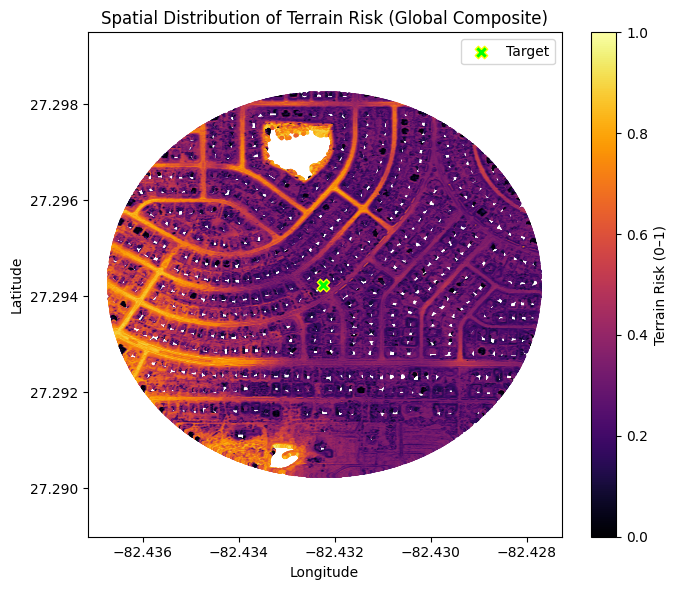

In [9]:
# ==========================================================================================
# TERRAIN RISK MODEL FROM DEM — Single-Point Score Only (English Output)
# ==========================================================================================
import os
import numpy as np
import pandas as pd
import rasterio
from rasterio.transform import xy
from pyproj import Transformer
from scipy.ndimage import uniform_filter
import matplotlib.pyplot as plt
# %matplotlib inline  # uncomment if running in Jupyter

# ----------------------- 1) Parameters -----------------------
tif_path        = "/Users/yaoyiyang/Desktop/Uchicago-elevation/outputs/4032_Palau_Dr_100m/dem_500m_dtm.tif"
lat, lon        = 27.294239, -82.432216       # Target location (WGS84)

gamma           = 4.0                          # Power for global_score (enhance low-lying contrast)
res_window_m    = 10.0                         # Window (m) for local mean elevation in delta

# ✅ Global model weights
WEIGHTS = dict(global_=0.50, delta=0.20, slope=0.20, asin=0.05, acos=0.05)

print(f"Processing DEM: {tif_path}")

# ----------------------- 2) Read DEM & Coordinates -----------------------
with rasterio.open(tif_path) as src:
    dem       = src.read(1).astype(float)
    transform = src.transform
    nodata    = src.nodata
    src_crs   = src.crs
    H_px, W_px = dem.shape
    res_x, res_y = src.res  # meters per pixel

if nodata is not None:
    dem[dem == nodata] = np.nan

rows, cols = np.indices((H_px, W_px))
xs, ys = xy(transform, rows.ravel(), cols.ravel())

lons, lats = Transformer.from_crs(src_crs, "EPSG:4326", always_xy=True).transform(xs, ys)

# ----------------------- 3) Terrain Derivatives -----------------------
dz_dy, dz_dx = np.gradient(dem, res_y, res_x)
slope  = np.degrees(np.hypot(dz_dx, dz_dy))
aspect = (90.0 - np.degrees(np.arctan2(dz_dy, -dz_dx))) % 360.0

# Local mean elevation (for delta)
win_px = max(3, int(round(res_window_m / float(res_x))))
filled = np.where(~np.isnan(dem), dem, 0.0)
valid  = (~np.isnan(dem)).astype(float)

sum_kern   = uniform_filter(filled, size=win_px, mode="constant")
count_kern = uniform_filter(valid,  size=win_px, mode="constant")
avg_dem    = sum_kern / np.where(count_kern == 0, np.nan, count_kern)

delta_dem = dem - avg_dem

# ----------------------- 3.5) Delta-based Risk -----------------------
delta_r = -delta_dem.ravel()
valid_delta = np.isfinite(delta_r)
if valid_delta.any():
    p1, p99 = np.percentile(delta_r[valid_delta], [1, 99])
else:
    p1, p99 = 0.0, 1.0
delta_r_clip = np.clip(delta_r, p1, p99)
dmin, dmax = np.nanmin(delta_r_clip), np.nanmax(delta_r_clip)
delta_risk = (delta_r_clip - dmin) / (dmax - dmin + 1e-12)

# ----------------------- 4) Flatten to DataFrame -----------------------
df = pd.DataFrame({
    "lat": lats,
    "lon": lons,
    "elevation": dem.ravel(),
    "slope": slope.ravel(),
    "aspect_sin": np.sin(np.deg2rad(aspect.ravel())),
    "aspect_cos": np.cos(np.deg2rad(aspect.ravel())),
    "avg_elevation": avg_dem.ravel(),
    "delta_elevation": delta_dem.ravel(),
    "delta_risk": delta_risk,
})
df.dropna(inplace=True)
print(f"✅ DEM grid points: {len(df):,}")

# ----------------------- 5) Global Flood Components -----------------------
df["elev_pct"]     = df["elevation"].rank(pct=True)
df["global_score"] = (1 - df["elev_pct"]) ** gamma
df["slope_risk"]   = 1 - df["slope"].rank(pct=True)

for col in ("aspect_sin", "aspect_cos"):
    rc = f"{col}_risk"
    v  = df[col].abs()
    lo, hi = v.min(), v.max()
    df[rc] = (v - lo) / (hi - lo + 1e-12)

df["flood_risk_raw"] = (
      WEIGHTS["global_"] * df["global_score"]
    + WEIGHTS["delta"]   * df["delta_risk"]
    + WEIGHTS["slope"]   * df["slope_risk"]
    + WEIGHTS["asin"]    * df["aspect_sin_risk"]
    + WEIGHTS["acos"]    * df["aspect_cos_risk"]
)

mn, mx = df["flood_risk_raw"].min(), df["flood_risk_raw"].max()
df["flood_risk_norm"] = (df["flood_risk_raw"] - mn) / (mx - mn + 1e-12)

# ----------------------- 6) Target cell -----------------------
def haversine(lat1, lon1, lat2, lon2):
    R = 6371000.0
    lat1, lat2 = np.radians(lat1), np.radians(lat2)
    dlat = lat2 - lat1
    dlon = np.radians(lon2 - lon1)
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lat2)*np.sin(dlon/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

df["dist_m"] = haversine(lat, lon, df["lat"], df["lon"])
idx_target   = df["dist_m"].idxmin()
target_lat   = df.at[idx_target, "lat"]
target_lon   = df.at[idx_target, "lon"]
target_risk  = float(df.at[idx_target, "flood_risk_norm"])

global_percentile = float(df["flood_risk_norm"].rank(pct=True).loc[idx_target] * 100.0)
higher_pct = max(0.0, min(100.0, 100.0 - global_percentile))

# ----------------------- 7) English human-readable output -----------------------
print("\n🏠 Target Location:")
print(f"   Lon={target_lon:.6f}, Lat={target_lat:.6f}")
print(f"The model estimates a terrain risk score of {target_risk:.3f} for this location,")
print(f"which ranks at the {global_percentile:.1f}th percentile across the entire area,")
print(f"meaning it is higher and less flood-prone than about {higher_pct:.1f}% of the terrain in this DEM region.")

# ----------------------- 8) Visualization -----------------------
plt.figure(figsize=(7,6))
sc = plt.scatter(df["lon"], df["lat"], c=df["flood_risk_norm"], s=2, cmap="inferno")
plt.scatter(target_lon, target_lat, c="lime", s=80, marker="X", edgecolor="yellow", label="Target")
plt.colorbar(sc, label="Terrain Risk (0–1)")
plt.title("Spatial Distribution of Terrain Risk (Global Composite)")
plt.xlabel("Longitude"); plt.ylabel("Latitude")
plt.axis("equal"); plt.legend()
plt.tight_layout()

out_dir = os.path.dirname(tif_path)
out_map = os.path.join(out_dir, "figure_flood_risk_map.png")
# Optional: plt.savefig(out_map, dpi=200)
plt.show()


In [6]:
from pathlib import Path

# 你原来的参数
tif_path = "/Users/yaoyiyang/Desktop/Uchicago-elevation/outputs/18_Good_Friend_Dr_100m/dem_500m_dtm.tif"
lat, lon = 40.969348, -72.241637

NODATA = -9999.0
GAMMA = 4.0
RES_WINDOW_M = 10.0
WEIGHTS = dict(global_=0.50, delta=0.20, slope=0.20, asin=0.05, acos=0.05)

# 输出 png 路径：随便叫一个名字
OUT_PNG = "/Users/yaoyiyang/Desktop/Uchicago-elevation/outputs/18_Good_Friend_Dr_100m/terrain_risk_ipynb.png"

# --- 读 DEM & 派生量 ---
dem_500, meta_500 = load_dem(tif_path, nodata=NODATA)
deriv = derive_slope_aspect_curvature(dem_500["arr"], res_x=1.0, res_y=1.0)
slope_500 = deriv["slope"]
aspect_500 = deriv["aspect"]

# --- 调用计算（注意这里传 OUT_PNG，不是 None）---
global_risk_info = compute_global_composite_risk_map(
    dem_arr_500=dem_500["arr"],
    slope_500=slope_500,
    aspect_500=aspect_500,
    meta_500=meta_500,
    lat=float(lat),
    lon=float(lon),
    gamma=float(GAMMA),
    res_window_m=float(RES_WINDOW_M),
    weights=WEIGHTS,
    out_png_path=OUT_PNG,
)

# --- 打印我们真正关心的 score ---
print("\n[Terrain Risk Score]")
print(f"  target_risk (0=最安全, 1=最高风险): {global_risk_info['target_risk']:.3f}")
print(f"  global_percentile (危险程度百分位): {global_risk_info['global_percentile']:.1f}%")
print(f"  higher_pct (比它更安全的比例): {global_risk_info['higher_pct']:.1f}%")
print(f"  debug png saved at: {global_risk_info['out_png_path']}")



[DEBUG] Building vs 500m DEM (terrain risk)
  Footprint median elevation      : 21.045 m
  Percentile in 500m (by elevation): 97.63%
  global_score: footprint median=0.000, all 5/95pct=[0.000, 0.815]
  delta_risk: footprint median=0.000, all 5/95pct=[0.320, 0.741]
  slope_risk: footprint median=0.013, all 5/95pct=[0.050, 0.950]

[Terrain Risk Score]
  target_risk (0=最安全, 1=最高风险): 0.050
  global_percentile (危险程度百分位): 0.9%
  higher_pct (比它更安全的比例): 99.1%
  debug png saved at: /Users/yaoyiyang/Desktop/Uchicago-elevation/outputs/18_Good_Friend_Dr_100m/terrain_risk_ipynb.png
